In [ ]:
import marimo as mo
import numpy as np
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# Classification in 2D

This notebook illustrates how to train a neural network to data that is not linearly separately. The features extraction are separable after training of the model.

First, we generate some data.

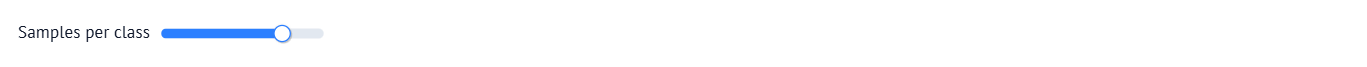

In [ ]:
# Slider to control number of samples per class
samples_slider = mo.ui.slider(50, 500, step=10, value=400, label="Samples per class")
samples_slider

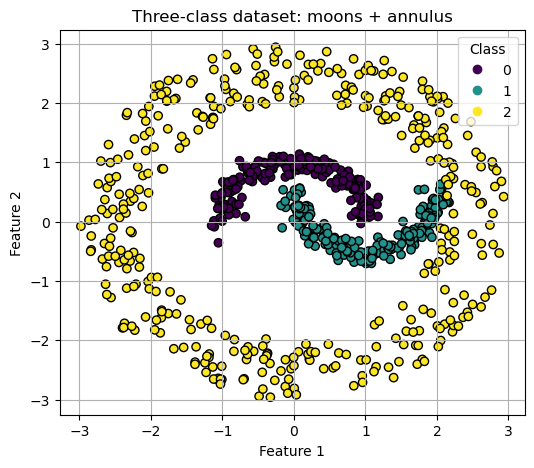

In [ ]:
def _generate_dataset(n):
    # Two interleaving moons (already two classes)
    X_moons, y_moons = make_moons(n_samples=n, noise=0.1, random_state=42)

    # Annulus (third class) that encloses the moons
    r_inner, r_outer = 2.0, 3.0
    theta = np.random.rand(n) * 2 * np.pi
    r = np.sqrt(np.random.rand(n) * (r_outer**2 - r_inner**2) + r_inner**2)
    X_annulus = np.column_stack((r * np.cos(theta), r * np.sin(theta)))
    y_annulus = np.full(n, 2)

    # Combine
    X = np.vstack((X_moons, X_annulus))
    y = np.concatenate((y_moons, y_annulus))
    return X, y

# Generate data based on slider value
X, y = _generate_dataset(samples_slider.value)

# Plot
plt.figure(figsize=(6, 5))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolor="k")
plt.title("Three‑class dataset: moons + annulus")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="Class")

# Return UI element and the plot
plt.gca()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Here is the architecture of the neural network that will be used to fit the data.

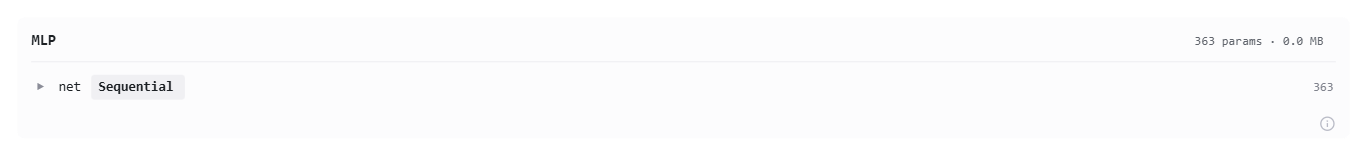

In [ ]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    """Three‑hidden‑layer perceptron for the 2‑D three‑class dataset."""
    def __init__(self, input_dim: int = 2, hidden_dims: tuple[int, int, int] = (16, 16, 2), out_dim: int = 3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], hidden_dims[2]),
            nn.ReLU(),
            nn.Linear(hidden_dims[2], out_dim)
        )

    def forward(self, x):
        return self.net(x)

# Instantiate the model
mlp_model = MLP()
mlp_model

Pressing the button below will trigger training and evaluating the neural network.

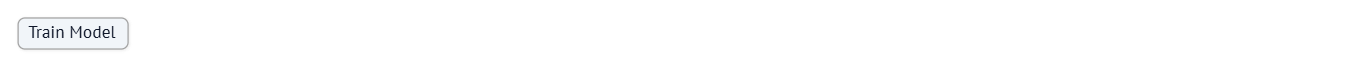

In [ ]:
run_button = mo.ui.run_button(label='Train Model')
run_button

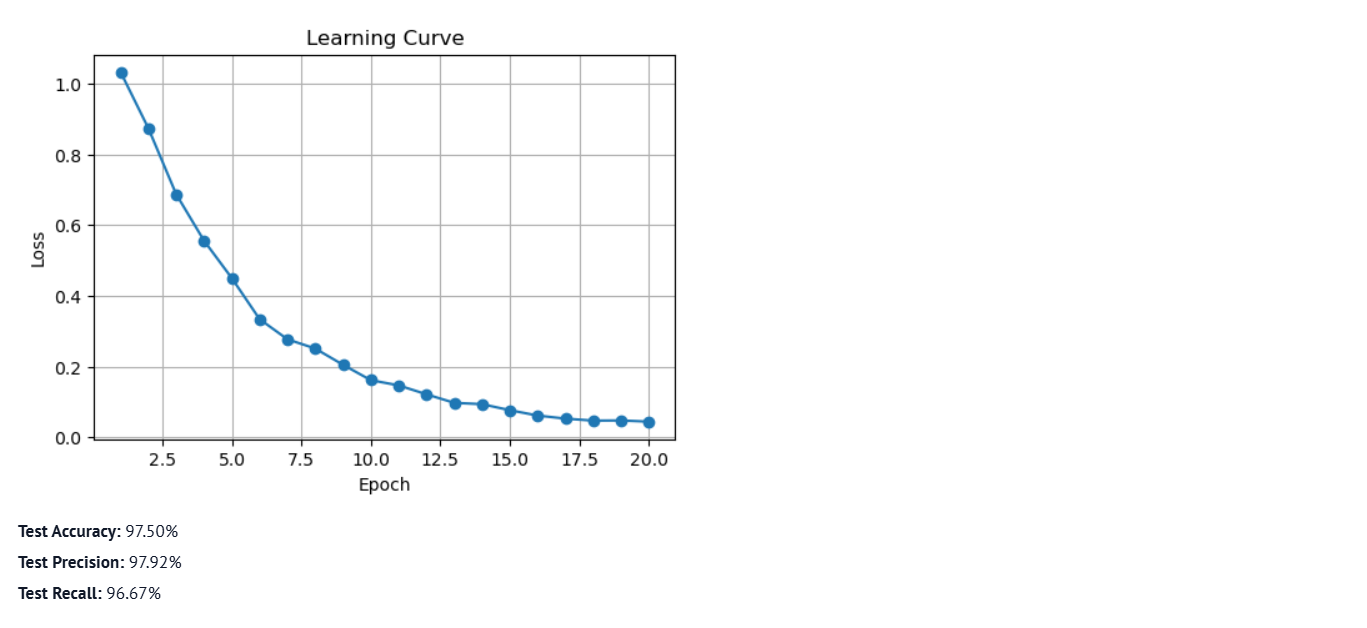

In [ ]:
mo.stop(not run_button.value)

# Convert NumPy arrays to torch tensors
X_train_t = torch.from_numpy(X_train).float()
y_train_t = torch.from_numpy(y_train).long()
X_test_t = torch.from_numpy(X_test).float()
y_test_t = torch.from_numpy(y_test).long()

# Data loader for mini‑batch training
train_dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

# Loss, optimizer and training settings
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.01)
epochs = 20
_train_losses = []

# Training loop
mlp_model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = mlp_model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_loader.dataset)
    _train_losses.append(epoch_loss)

# Plot learning curve
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), _train_losses, marker="o")
plt.title("Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

# Evaluation on test set
from sklearn.metrics import precision_score, recall_score

mlp_model.eval()
with torch.no_grad():
    test_logits = mlp_model(X_test_t)
    test_preds = torch.argmax(test_logits, dim=1).numpy()
    test_accuracy = (test_preds == y_test).mean()
    test_precision = precision_score(y_test, test_preds, average="macro")
    test_recall = recall_score(y_test, test_preds, average="macro")

# Display results together with the plot
mo.vstack([
    plt.gca(),
    mo.md(
        f"**Test Accuracy:** {test_accuracy:.2%}<br>"
        f"**Test Precision:** {test_precision:.2%}<br>"
        f"**Test Recall:** {test_recall:.2%}"
    )
])

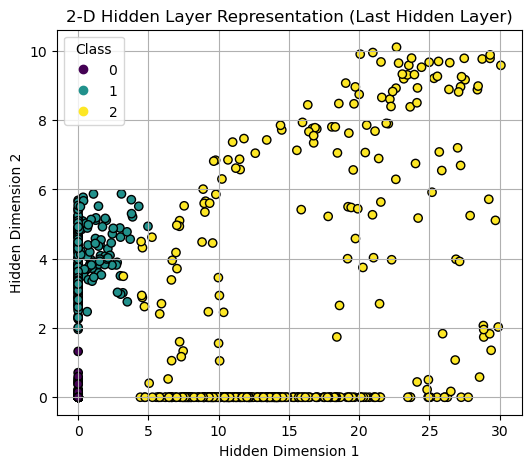

In [ ]:
mo.stop(not run_button.value)

# Compute hidden representations from the last hidden layer (2‑D) for the entire dataset
# Extract the sub‑network up to the last hidden ReLU (includes Linear → ReLU)
_feature_extractor = nn.Sequential(*list(mlp_model.net.children())[:6])

# Convert full dataset to torch tensor
_X_full_t = torch.from_numpy(X).float()

# Get 2‑D hidden features
hidden_vals = _feature_extractor(_X_full_t).detach().cpu().numpy()

# Plot the hidden space, colored by original class label
plt.figure(figsize=(6, 5))
scatter_hidden = plt.scatter(
    hidden_vals[:, 0],
    hidden_vals[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="k"
)
plt.title("2‑D Hidden Layer Representation (Last Hidden Layer)")
plt.xlabel("Hidden Dimension 1")
plt.ylabel("Hidden Dimension 2")
plt.grid(True)
plt.legend(*scatter_hidden.legend_elements(), title="Class")

# Return the matplotlib Axes object for marimo to render
plt.gca()

Plotting the 2D features obtained form the last hidden layer.